<a href="https://colab.research.google.com/github/DL4CV-NPTEL/2026/blob/main/notebooks/Week%202/Week_2_Lecture_1_New.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📺 [Lecture video](https://www.youtube.com/watch?v=9r8ph2pb9aw) &nbsp;|&nbsp; 📄 [Slides](https://github.com/DL4CV-NPTEL/2026/blob/main/Slides/Week%202/DL4CV_Week02_Part01.pdf)

In [ ]:
# Week 2, Lecture 1: Edge detection
from IPython.display import HTML, display

VIDEO_ID = "9r8ph2pb9aw"

# YouTube's official embed markup. The `allow` list delegates the permissions the
# player needs; Colab renders outputs inside a nested iframe and without that
# delegation the player aborts with "Error 153".
display(HTML(f"""
<iframe width="720" height="405"
        src="https://www.youtube.com/embed/{VIDEO_ID}"
        title="YouTube video player" frameborder="0"
        allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share"
        referrerpolicy="strict-origin-when-cross-origin"
        allowfullscreen></iframe>
<p><a href="https://www.youtube.com/watch?v={VIDEO_ID}" target="_blank">Watch on YouTube</a></p>
"""))

Watch on YouTube

# Week 2, Lecture 1: Edge Detection

**NPTEL Deep Learning for Computer Vision** | Prof. Vineeth N Balasubramanian, IIT Hyderabad

Companion notebook for **§2.1 Edge Detection**.

**What you will learn**

- Treat an edge as rapid intensity change, and compute derivatives by convolution with finite differences.
- Compare the **Prewitt, Sobel and Roberts** filters, and read gradient strength and orientation.
- See why noise forces you to **smooth first**, and use the derivative-of-Gaussian shortcut.
- Find edges with the **Laplacian of Gaussian** and its zero-crossings.
- Assemble the **Canny detector**: non-maximum suppression followed by hysteresis thresholding.

**Contents**
1. An edge is a place of rapid intensity change
2. Derivatives as convolution: finite differences
3. Finite difference filters: Prewitt, Sobel, Roberts
4. The image gradient: strength and orientation
5. Noise, and why we smooth first
6. Derivative theorem of convolution: derivative of Gaussian
7. Second derivative: Laplacian of Gaussian and zero-crossings
8. Non-maximum suppression
9. Hysteresis thresholding
10. The Canny edge detector
11. Beyond Canny: learned edge detection

**How to run**  Runs on Colab or a local Jupyter, CPU only. Every image is bundled with `scikit-image`, so nothing is downloaded. Run the setup cell first, then go top to bottom.

## Review

The earlier lectures built up convolution and linear filtering. Edge detection is the first place those tools pay off as a vision task. The plan is simple to state: an edge is where image intensity changes sharply, so a derivative will be large there, and a derivative of a discrete signal is itself a convolution with a small kernel. The rest of the notebook turns that one idea into a detector that is robust to noise, returns thin one-pixel contours, and links them into connected curves, which is exactly the Canny pipeline.

## Setup

Everything uses images bundled with `scikit-image`, so the notebook runs offline. We apply named kernels with `correlate` (the kernel slides without being flipped), so the matrices shown in code match the ones on the slides.

In [3]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
from scipy import ndimage as ndi
from skimage import data, util, color

np.random.seed(0)
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['image.cmap']     = 'gray'
plt.rcParams['figure.dpi']     = 85

def load_gray(image):
    # float grayscale image in [0, 1]
    return color.rgb2gray(image) if image.ndim == 3 else util.img_as_float(image)

def show(ax, im, title='', cmap='gray'):
    ax.imshow(im, cmap=cmap); ax.set_title(title); ax.axis('off')

cam = load_gray(data.camera())

## 1. An edge is a place of rapid intensity change

Take a single horizontal scanline through an image and plot intensity against position. A clean edge shows up as a step, and its derivative shows up as a sharp peak whose location marks the edge. So locating edges in 1D reduces to finding extrema of the derivative. The synthetic step on the left makes this exact; the real scanline on the right shows the same structure buried in texture.

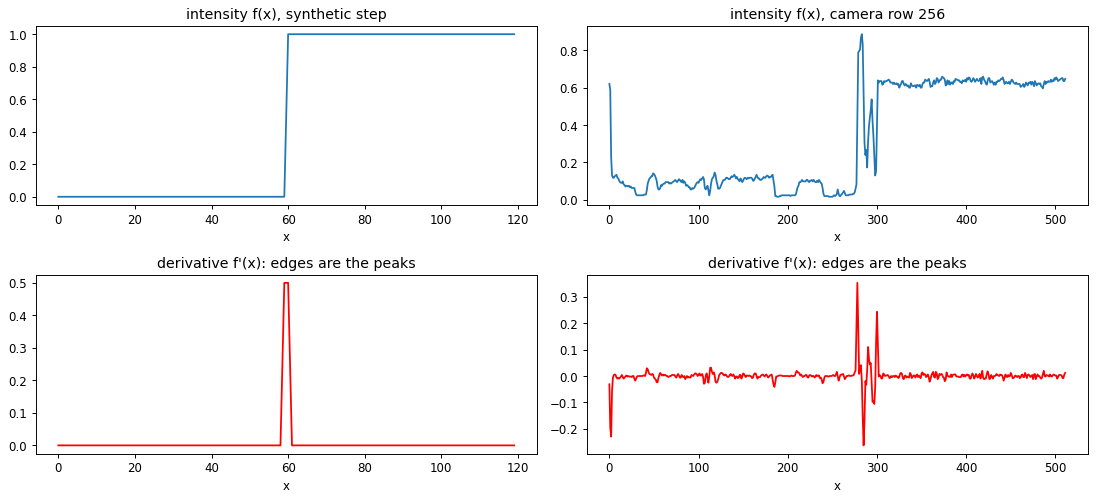

In [4]:
# synthetic step edge and a real scanline from the camera image
step = np.concatenate([np.zeros(60), np.ones(60)])
row  = cam[256]                                   # one row through the middle

fig, ax = plt.subplots(2, 2, figsize=(13, 6))
for col, (sig, name) in enumerate([(step, 'synthetic step'), (row, 'camera row 256')]):
    d = np.gradient(sig)                           # discrete derivative
    ax[0, col].plot(sig);  ax[0, col].set_title(f'intensity f(x), {name}'); ax[0, col].set_xlabel('x')
    ax[1, col].plot(d, 'r'); ax[1, col].set_title("derivative f'(x): edges are the peaks"); ax[1, col].set_xlabel('x')
plt.tight_layout(); plt.show()

## 2. Derivatives as convolution: finite differences

For a discrete image the partial derivative is approximated by a finite difference, $\partial f/\partial x \approx f(x{+}1, y) - f(x{-}1, y)$ for the central form. That subtraction of neighbouring pixels is a correlation with the 1D kernel $[-1, 0, 1]$, and the vertical kernel $[-1, 0, 1]^\top$ gives $\partial f/\partial y$. The $x$ derivative responds to vertical edges and the $y$ derivative to horizontal edges, which is why each result below highlights one orientation.

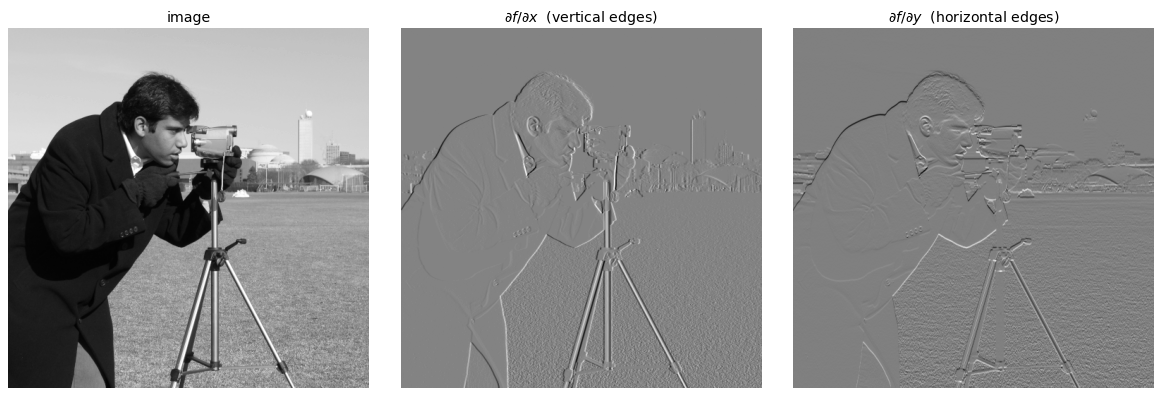

In [5]:
kx = np.array([[-1, 0, 1]]) / 2.0                 # central difference along x
ky = kx.T                                          # along y

Ix = ndi.correlate(cam, kx)
Iy = ndi.correlate(cam, ky)

fig, ax = plt.subplots(1, 3, figsize=(14, 4.6))
show(ax[0], cam, 'image')
show(ax[1], Ix, r'$\partial f/\partial x$  (vertical edges)')
show(ax[2], Iy, r'$\partial f/\partial y$  (horizontal edges)')
plt.tight_layout(); plt.show()

## 3. Finite difference filters: Prewitt, Sobel, Roberts

A bare difference is noisy because it uses a single pixel on each side. The classic operators add a small amount of smoothing along the edge. **Prewitt** averages three rows equally, **Sobel** weights the centre row by two (a mild Gaussian-like blur), and **Roberts** is a compact $2\times 2$ diagonal difference. Sobel is the usual default: cheap, separable, and noticeably steadier than the raw difference.

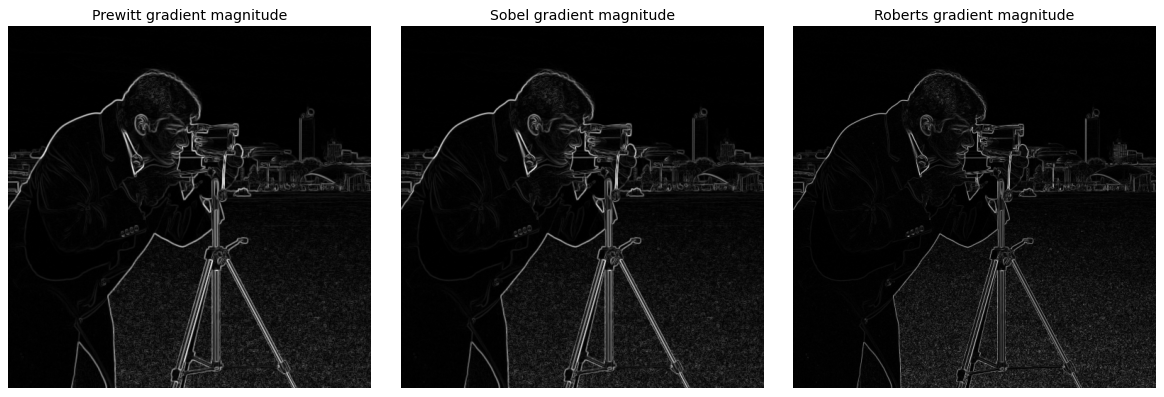

In [6]:
ops = {
    'Prewitt': (np.array([[-1,0,1],[-1,0,1],[-1,0,1]], float),
                np.array([[-1,-1,-1],[0,0,0],[1,1,1]], float)),
    'Sobel':   (np.array([[-1,0,1],[-2,0,2],[-1,0,1]], float),
                np.array([[-1,-2,-1],[0,0,0],[1,2,1]], float)),
    'Roberts': (np.array([[1,0],[0,-1]], float),
                np.array([[0,1],[-1,0]], float)),
}

def grad_mag(im, kx, ky):
    return np.hypot(ndi.correlate(im, kx), ndi.correlate(im, ky))

fig, ax = plt.subplots(1, 3, figsize=(14, 4.6))
for a, (name, (gx, gy)) in zip(ax, ops.items()):
    show(a, grad_mag(cam, gx, gy), f'{name} gradient magnitude')
plt.tight_layout(); plt.show()

## 4. The image gradient: strength and orientation

Stacking the two partials gives the gradient $\nabla f = [\,\partial f/\partial x,\ \partial f/\partial y\,]$, which points in the direction of fastest intensity increase. Its magnitude $\lVert \nabla f \rVert = \sqrt{f_x^2 + f_y^2}$ is the edge strength, and its angle $\theta = \operatorname{atan2}(f_y, f_x)$ is the orientation of the edge normal. Below, brightness encodes strength and hue encodes orientation, so edges of different directions take different colours.

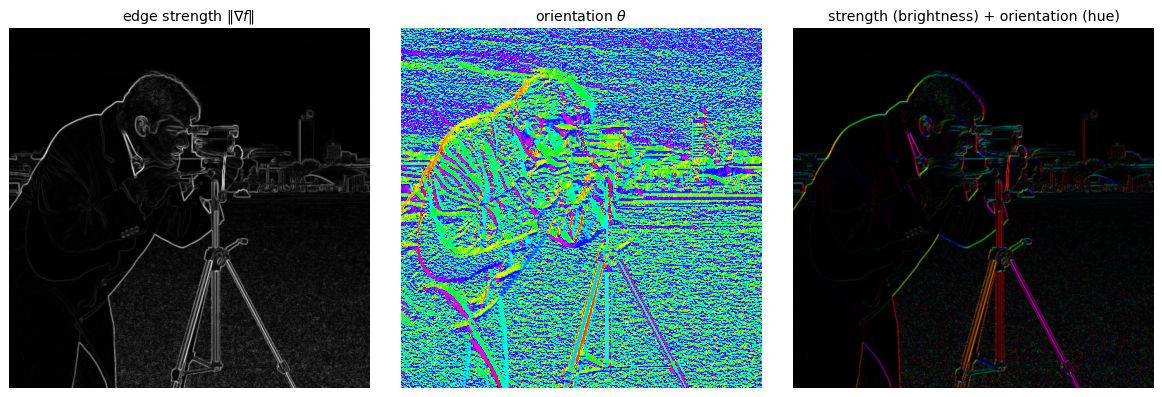

In [7]:
gx, gy = ndi.correlate(cam, ops['Sobel'][0]), ndi.correlate(cam, ops['Sobel'][1])
mag    = np.hypot(gx, gy)
theta  = np.arctan2(gy, gx)

# map orientation to hue, strength to value
hsv = np.zeros(cam.shape + (3,))
hsv[..., 0] = (np.degrees(theta) % 180) / 180.0    # hue from edge direction
hsv[..., 1] = 1.0
hsv[..., 2] = mag / mag.max()                       # brightness from edge strength

fig, ax = plt.subplots(1, 3, figsize=(14, 4.6))
show(ax[0], mag, r'edge strength $\|\nabla f\|$')
show(ax[1], theta, r'orientation $\theta$', cmap='hsv')
show(ax[2], hsv_to_rgb(hsv), 'strength (brightness) + orientation (hue)')
plt.tight_layout(); plt.show()

## 5. Noise, and why we smooth first

Differentiation amplifies high frequencies, so on a noisy signal the raw derivative is dominated by noise and the edge is lost. The fix is to low-pass first: smooth with a Gaussian $g$, then differentiate. The edge now appears as a clean peak in $\frac{d}{dx}(f * g)$. The amount of smoothing trades robustness against localization, a tension the Gaussian scale $\sigma$ controls.

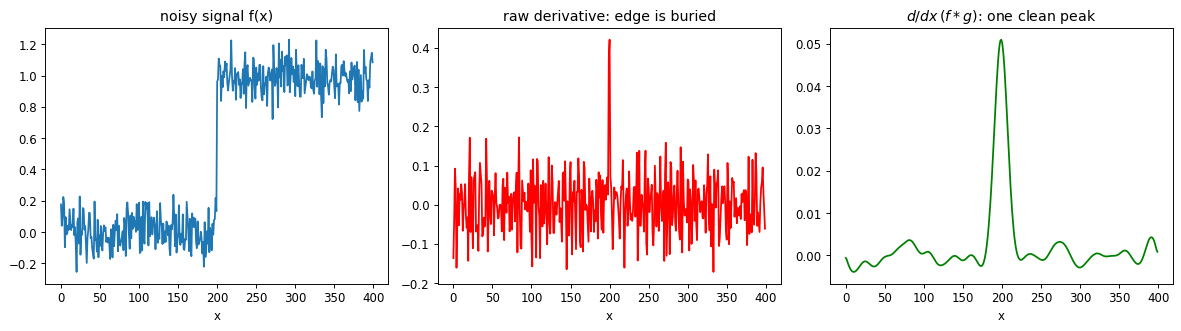

In [8]:
x = np.linspace(0, 1, 400)
clean = (x > 0.5).astype(float)
noisy = clean + 0.10 * np.random.randn(x.size)
smoothed = ndi.gaussian_filter1d(noisy, 8)

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].plot(noisy); ax[0].set_title('noisy signal f(x)')
ax[1].plot(np.gradient(noisy), 'r'); ax[1].set_title("raw derivative: edge is buried")
ax[2].plot(np.gradient(smoothed), 'g'); ax[2].set_title(r'$d/dx\,(f*g)$: one clean peak')
for a in ax: a.set_xlabel('x')
plt.tight_layout(); plt.show()

## 6. Derivative theorem of convolution: derivative of Gaussian

Convolution is associative and differentiation is a convolution, so $\frac{d}{dx}(f * g) = f * \frac{d}{dx} g$. We can therefore differentiate the Gaussian once, offline, and convolve the image with that single **derivative-of-Gaussian** (DoG) kernel, smoothing and differentiating in one pass. The $x$ and $y$ DoG kernels below sum to zero and act as oriented edge filters; their magnitude is a noise-robust gradient.

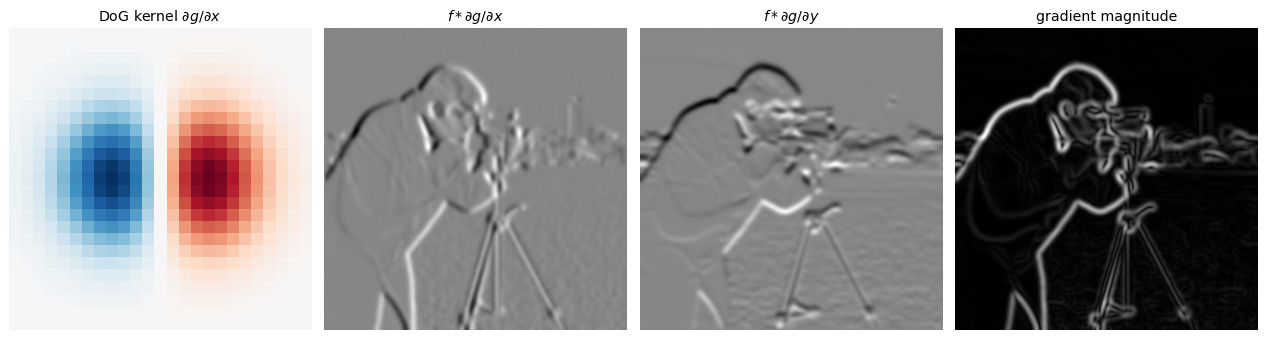

In [9]:
def gaussian_2d(size, sigma):
    ax = np.arange(-(size//2), size//2 + 1)
    xx, yy = np.meshgrid(ax, ax)
    g = np.exp(-(xx**2 + yy**2) / (2*sigma**2)) / (2*np.pi*sigma**2)
    return xx, yy, g

s = 4
xx, yy, g = gaussian_2d(25, s)
dog_x = -xx / s**2 * g                              # d/dx of the Gaussian
dog_y = -yy / s**2 * g

# apply DoG directly with scipy's order argument (separable, fast)
Ix = ndi.gaussian_filter(cam, s, order=[0, 1])      # axis 1 = x
Iy = ndi.gaussian_filter(cam, s, order=[1, 0])      # axis 0 = y
dog_mag = np.hypot(Ix, Iy)

fig, ax = plt.subplots(1, 4, figsize=(15, 4))
show(ax[0], dog_x, r'DoG kernel $\partial g/\partial x$', cmap='RdBu')
show(ax[1], Ix, r'$f * \partial g/\partial x$')
show(ax[2], Iy, r'$f * \partial g/\partial y$')
show(ax[3], dog_mag, 'gradient magnitude')
plt.tight_layout(); plt.show()

## 7. Second derivative: Laplacian of Gaussian and zero-crossings

An edge is a peak in the first derivative, which is a **zero-crossing** in the second derivative. The orientation-free second-order operator is the Laplacian $\nabla^2 f = f_{xx} + f_{yy}$; combined with Gaussian smoothing it becomes the **Laplacian of Gaussian** (LoG), the familiar Mexican-hat kernel. Edges are then the points where the LoG response changes sign. This is sharp but more sensitive to noise than the gradient route, visible in the busier zero-crossing map.

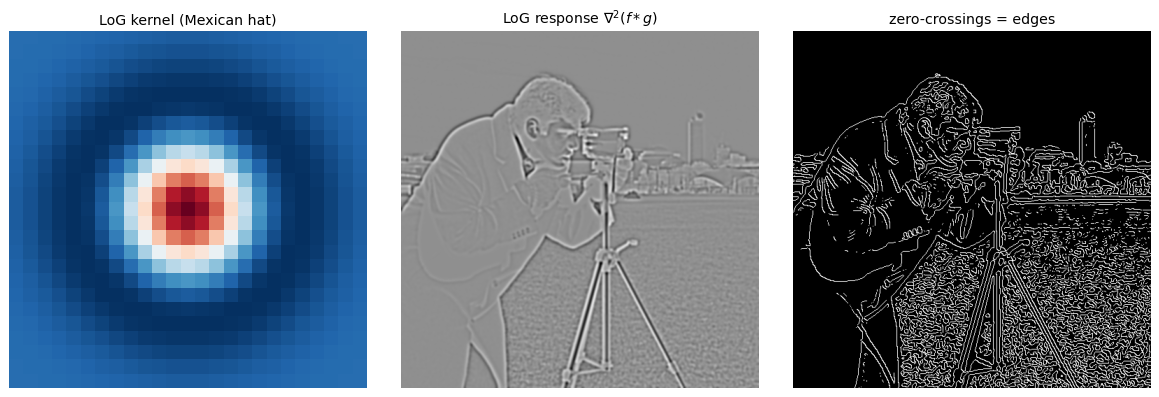

In [10]:
s = 2
xx, yy, g = gaussian_2d(25, 4)
log_kernel = (xx**2 + yy**2 - 2*4**2) / 4**4 * g     # Laplacian of Gaussian
log_resp   = ndi.gaussian_laplace(cam, sigma=s)

def zero_crossings(L, rel=0.03):
    zc = np.zeros_like(L, dtype=bool)
    for axis in (0, 1):
        flip = np.diff(np.sign(L), axis=axis) != 0   # sign change along this axis
        pad = [(0, 0), (0, 0)]; pad[axis] = (0, 1)
        zc |= np.pad(flip, pad)
    strength = np.hypot(*np.gradient(L))             # keep only strong crossings
    return zc & (strength > rel * strength.max())

fig, ax = plt.subplots(1, 3, figsize=(14, 4.6))
show(ax[0], log_kernel, 'LoG kernel (Mexican hat)', cmap='RdBu')
show(ax[1], log_resp, r'LoG response $\nabla^2(f*g)$')
show(ax[2], zero_crossings(log_resp), 'zero-crossings = edges')
plt.tight_layout(); plt.show()

## 8. Non-maximum suppression

The gradient magnitude is a thick ridge, but a good detector returns one pixel per edge. **Non-maximum suppression** keeps a pixel only if its magnitude is a local maximum along the gradient direction, comparing against the two neighbours that straddle the edge. We quantize the direction to the nearest of four orientations (0, 45, 90, 135 degrees) and pick neighbours accordingly; an exact version interpolates between pixels. The result is a thin one-pixel ridge.

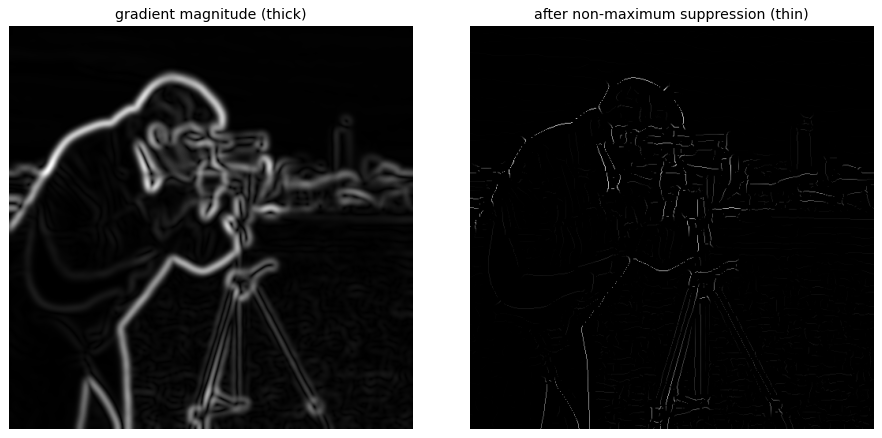

In [11]:
def non_max_suppression(mag, theta):
    out = np.zeros_like(mag)
    angle = np.degrees(theta) % 180
    p = np.pad(mag, 1)                               # 1-pixel border to avoid edge checks
    M, N = mag.shape
    for i in range(M):
        for j in range(N):
            a, ii, jj = angle[i, j], i + 1, j + 1
            if   a < 22.5 or a >= 157.5: nb = (p[ii, jj+1], p[ii, jj-1])     # horizontal grad
            elif a < 67.5:               nb = (p[ii-1, jj+1], p[ii+1, jj-1]) # diagonal
            elif a < 112.5:              nb = (p[ii-1, jj], p[ii+1, jj])     # vertical grad
            else:                        nb = (p[ii-1, jj-1], p[ii+1, jj+1]) # anti-diagonal
            if mag[i, j] >= max(nb):
                out[i, j] = mag[i, j]
    return out

thin = non_max_suppression(dog_mag, np.arctan2(Iy, Ix))

fig, ax = plt.subplots(1, 2, figsize=(11, 5.2))
show(ax[0], dog_mag, 'gradient magnitude (thick)')
show(ax[1], thin, 'after non-maximum suppression (thin)')
plt.tight_layout(); plt.show()

## 9. Hysteresis thresholding

A single threshold either breaks strong edges into dashes or floods the image with noise. Hysteresis uses two: pixels above `high` are confirmed edges, pixels below `low` are discarded, and pixels in between are kept only if they connect to a confirmed edge. We implement it by labelling all above-`low` pixels into connected components and keeping any component that contains an above-`high` pixel, which links faint but well-connected segments while dropping isolated weak responses.

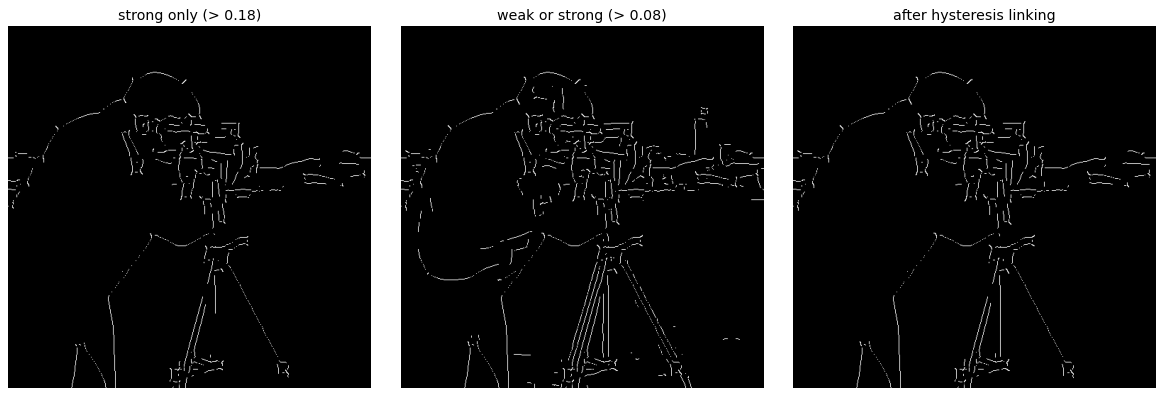

In [12]:
def hysteresis(mag, low, high):
    strong = mag >= high
    weak   = mag >= low
    labels, n = ndi.label(weak)                      # connected components of weak-or-strong
    keep = np.zeros(n + 1, bool)
    keep[labels[strong]] = True                      # mark components touching a strong pixel
    keep[0] = False
    return keep[labels]

m = thin / thin.max()
low, high = 0.08, 0.18
edges = hysteresis(m, low, high)

fig, ax = plt.subplots(1, 3, figsize=(14, 4.6))
show(ax[0], m >= high, f'strong only (> {high})')
show(ax[1], m >= low, f'weak or strong (> {low})')
show(ax[2], edges, 'after hysteresis linking')
plt.tight_layout(); plt.show()

## 10. The Canny edge detector

Canny (1986) is exactly the four steps we just built, in order: smooth with a derivative of Gaussian, compute gradient magnitude and orientation, thin by non-maximum suppression, then link with hysteresis. It remains the standard classical detector because it scores well on the three criteria of good detection, good localization, and a single response per edge. Below we assemble our functions into one pass and compare with the reference implementation in `scikit-image`.

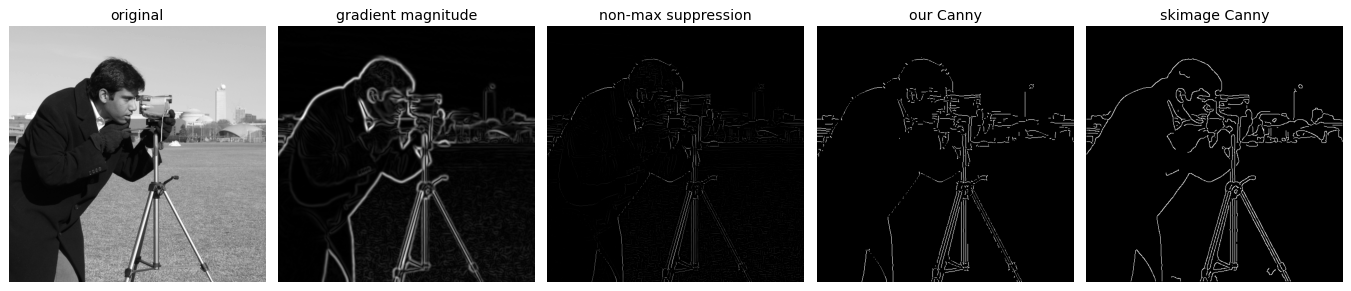

In [13]:
from skimage.feature import canny

def canny_edges(im, sigma=2, low=0.08, high=0.18):
    Ix = ndi.gaussian_filter(im, sigma, order=[0, 1])
    Iy = ndi.gaussian_filter(im, sigma, order=[1, 0])
    mag = np.hypot(Ix, Iy)
    thin = non_max_suppression(mag, np.arctan2(Iy, Ix))
    thin = thin / (thin.max() + 1e-12)
    return mag, thin, hysteresis(thin, low, high)

mag, thin, ours = canny_edges(cam, sigma=2)
ref = canny(cam, sigma=2)

fig, ax = plt.subplots(1, 5, figsize=(16, 3.6))
show(ax[0], cam, 'original')
show(ax[1], mag, 'gradient magnitude')
show(ax[2], thin, 'non-max suppression')
show(ax[3], ours, 'our Canny')
show(ax[4], ref, 'skimage Canny')
plt.tight_layout(); plt.show()

### Effect of the Gaussian scale $\sigma$

The single most important knob is the smoothing scale. A small $\sigma$ keeps fine detail and texture, a large $\sigma$ keeps only strong large-scale boundaries and gives cleaner but coarser contours. Choosing $\sigma$ is choosing the scale of edges you care about.

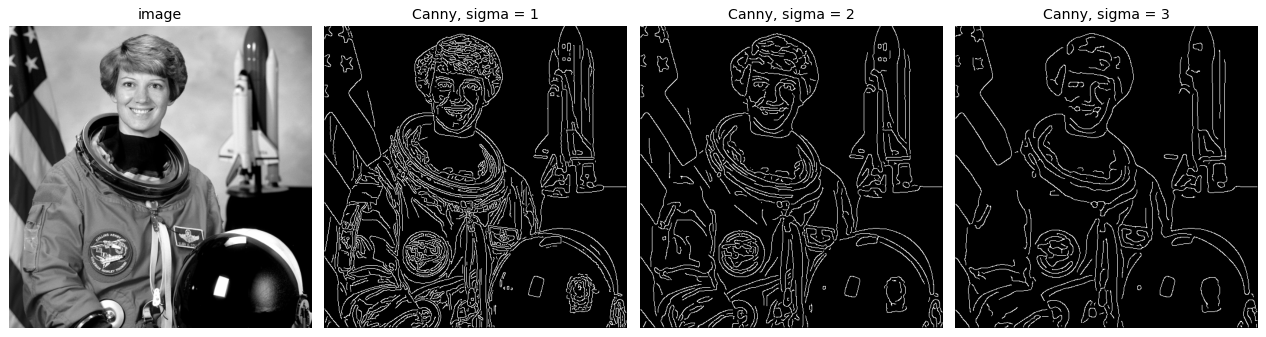

In [14]:
astro = load_gray(data.astronaut())
fig, ax = plt.subplots(1, 4, figsize=(15, 4))
show(ax[0], astro, 'image')
for a, sig in zip(ax[1:], [1, 2, 3]):
    show(a, canny(astro, sigma=sig), f'Canny, sigma = {sig}')
plt.tight_layout(); plt.show()

## 11. Beyond Canny: learned edge detection

Canny asks only whether intensity changes; it cannot tell a meaningful object boundary from busy texture or a soft shadow. Later work reframes edge detection as a learning problem trained on human-labelled boundaries. Martin et al. (2004) combine local brightness, colour, and texture cues into a learned **pB** boundary detector. Dollar and Zitnick (2013) train **structured random forests** to predict boundary patches quickly. Xie and Tu (2015) introduce **Holistically-Nested Edge Detection (HED)**, a fully convolutional network with deep supervision that, by learning multi-scale features end to end, approaches human agreement on the BSDS500 benchmark and clearly outperforms Canny. The throughline is a shift from a fixed gradient rule to features and boundaries learned from data.

---

## Key takeaways

| Concept | Key takeaway |
|---|---|
| **Edges** | Places of rapid intensity change; the derivative is large there |
| **Finite differences** | $\partial f/\partial x$ is a correlation with $[-1, 0, 1]$ |
| **Operators** | Prewitt, Sobel, Roberts add smoothing along the edge; Sobel is the usual default |
| **Gradient** | $\nabla f$ gives strength $\lVert\nabla f\rVert$ and orientation $\operatorname{atan2}(f_y, f_x)$ |
| **Smoothing first** | Differentiation amplifies noise, so low-pass before differentiating |
| **Derivative of Gaussian** | $\frac{d}{dx}(f*g) = f * \frac{d}{dx}g$: smooth and differentiate in one kernel |
| **Laplacian of Gaussian** | Second-order operator; edges are zero-crossings, sharper but noisier |
| **Non-max suppression** | Keep local maxima along the gradient to get one-pixel ridges |
| **Hysteresis** | Two thresholds plus connectivity link strong and well-connected weak edges |
| **Canny** | DoG, then magnitude and orientation, then NMS, then hysteresis |
| **$\sigma$** | Sets edge scale: small keeps detail, large keeps coarse boundaries |
| **Learned edges** | pB, structured forests, and HED learn boundaries from labelled data |

**Reading:** Szeliski, *Computer Vision: Algorithms and Applications*, Ch. 2 (and the edge-detection sections of Ch. 7 in the 2nd edition).

**References:** J. Canny (1986); D. Martin, C. Fowlkes, J. Malik (2004); P. Dollar, L. Zitnick (2013); P. Isola et al. (2014); S. Xie, Z. Tu (2015). Slide sources: K. Grauman, S. Seitz, R. Urtasun, D. Hoiem, N. Snavely, L. Lazebnik, J. Hays.